# DeLong comparison of partial-path AUCs

In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from navigoquest.utils.config import standard_dirs
from navigoquest.utils.figures import save_figure
from navigoquest.utils.stat_report import delong_paired_test, save_tests

In [2]:
# Directories
dirs = standard_dirs()
online_dir = dirs['cwd'] / '../data/online'
output_roc_dir = online_dir / "online_metric_roc_data"

# Settings, matching those used in 8_partial_paths
levels_use = [6, 8, 11]
prop_quantiles = np.linspace(0, 1, 6)
metrics_for_online = ['velocity', 'duration', 'path_length', 'average_curvature',
                      'boundary_affinity', 'frobenius_deviation', 'supremum_deviation',
                      'conformity', 'vector_conformity']

In [3]:
# Reload the exported ROC data written by 8_partial_paths.
# Each file holds the visiting-order labels and the logistic regression score
# for every metric, so the AUCs and LR scores below need no recomputation.
vocs_all = {}
logsco_all = {lvl: {item: [] for item in metrics_for_online} for lvl in levels_use}
auc_all = {lvl: {item: [] for item in metrics_for_online} for lvl in levels_use}

for lvl in levels_use:
    for quantile in prop_quantiles:
        filename = output_roc_dir / f"roc_data_lvl{lvl}_quantile{round(quantile, 3)}.csv"
        if not filename.is_file():
            raise FileNotFoundError(f"{filename} is missing; run 8_partial_paths first.")
        df = pd.read_csv(filename)

        vocs_all[lvl] = df['voc'].to_numpy()
        for item in metrics_for_online:
            logsco_now = df[item].to_numpy()
            logsco_all[lvl][item].append(logsco_now)

            fpr, tpr, _ = roc_curve(vocs_all[lvl], logsco_now)
            auc_all[lvl][item].append(auc(fpr, tpr))

print(f"Loaded ROC data for levels {levels_use} at {len(prop_quantiles)} quantiles")

Loaded ROC data for levels [6, 8, 11] at 6 quantiles


In [4]:
# Produced by 9_delong_tests.r, which reads the CSVs written by 8_partial_paths.
# Without it the AUC panel falls back to values without confidence intervals.
delong_dir = output_roc_dir / 'delong_results.csv'
plot_delong = delong_dir.exists()

if plot_delong:
    delong_df = pd.read_csv(delong_dir)
else:
    print(f'No DeLong results at {delong_dir}; run 9_delong_tests.r to generate them.')

In [5]:
if plot_delong:
    print(delong_df)

    level  quantile      auc1   auc1_se      auc2   auc2_se    pval_delong  \
0       6       0.0  0.611286  0.004144  0.799216  0.003341   0.000000e+00   
1       6       0.2  0.623126  0.004118  0.825750  0.003082   0.000000e+00   
2       6       0.4  0.644150  0.004016  0.842157  0.002898   0.000000e+00   
3       6       0.6  0.687106  0.003720  0.861771  0.002646   0.000000e+00   
4       6       0.8  0.864924  0.002246  0.936535  0.001519   0.000000e+00   
5       6       1.0  0.949607  0.001404  0.963542  0.000978   3.757770e-34   
6       8       0.0  0.635464  0.003857  0.690027  0.003530   2.468859e-63   
7       8       0.2  0.673595  0.003641  0.745180  0.003257  9.940834e-117   
8       8       0.4  0.721373  0.003309  0.771353  0.003055   3.766118e-71   
9       8       0.6  0.795195  0.002767  0.800699  0.002835   2.080883e-02   
10      8       0.8  0.907706  0.001834  0.855078  0.002414  2.429013e-184   
11      8       1.0  0.933487  0.001576  0.862391  0.002377   0.

In [6]:
if plot_delong:
    for lvl in levels_use:
        print(lvl)
        print(f'AUC')
        print(delong_df[delong_df['level'] == lvl]['auc1'].round(3))
        print(delong_df[delong_df['level'] == lvl]['auc2'].round(3))
        print(f'AUC_SE')
        print(delong_df[delong_df['level'] == lvl]['auc1_se'].round(3))
        print(delong_df[delong_df['level'] == lvl]['auc2_se'].round(3))
        print('\n')

6
AUC
0    0.611
1    0.623
2    0.644
3    0.687
4    0.865
5    0.950
Name: auc1, dtype: float64
0    0.799
1    0.826
2    0.842
3    0.862
4    0.937
5    0.964
Name: auc2, dtype: float64
AUC_SE
0    0.004
1    0.004
2    0.004
3    0.004
4    0.002
5    0.001
Name: auc1_se, dtype: float64
0    0.003
1    0.003
2    0.003
3    0.003
4    0.002
5    0.001
Name: auc2_se, dtype: float64


8
AUC
6     0.635
7     0.674
8     0.721
9     0.795
10    0.908
11    0.933
Name: auc1, dtype: float64
6     0.690
7     0.745
8     0.771
9     0.801
10    0.855
11    0.862
Name: auc2, dtype: float64
AUC_SE
6     0.004
7     0.004
8     0.003
9     0.003
10    0.002
11    0.002
Name: auc1_se, dtype: float64
6     0.004
7     0.003
8     0.003
9     0.003
10    0.002
11    0.002
Name: auc2_se, dtype: float64


11
AUC
12    0.639
13    0.657
14    0.689
15    0.795
16    0.882
17    0.917
Name: auc1, dtype: float64
12    0.647
13    0.729
14    0.765
15    0.840
16    0.876
17    0.869
Name: auc2, 

In [7]:
if plot_delong:
    for lvl in levels_use:
        print(lvl)
        print(delong_df[delong_df['level'] == lvl]['pval_delong'])
        print(delong_df[delong_df['level'] == lvl]['std_auc_diff'].round(3))
        print('\n')

6
0    0.000000e+00
1    0.000000e+00
2    0.000000e+00
3    0.000000e+00
4    0.000000e+00
5    3.757770e-34
Name: pval_delong, dtype: float64
0   -50.490
1   -55.853
2   -57.170
3   -55.968
4   -41.787
5   -12.185
Name: std_auc_diff, dtype: float64


8
6      2.468859e-63
7     9.940834e-117
8      3.766118e-71
9      2.080883e-02
10    2.429013e-184
11     0.000000e+00
Name: pval_delong, dtype: float64
6    -16.799
7    -22.967
8    -17.835
9     -2.311
10    28.955
11    41.530
Name: std_auc_diff, dtype: float64


11
12     4.335022e-02
13     1.170111e-77
14    5.717993e-103
15     1.432110e-76
16     7.885271e-04
17    2.377581e-196
Name: pval_delong, dtype: float64
12    -2.020
13   -18.654
14   -21.546
15   -18.520
16     3.357
17    29.894
Name: std_auc_diff, dtype: float64




In [8]:
# Paired DeLong tests (Duration vs. V-Conformity) in the journal's format:
# z = value, p = value, ΔAUC = value, 95% CI = [low, high] (no df: z-test).
# Written to statistical_tests/partial_paths_delong_tests.csv and .txt
if plot_delong:
    delong_tests = [
        delong_paired_test(
            row.auc1, row.auc2, row.std_auc_diff, row.pval_delong,
            name1='Duration', name2='V-Conformity',
            auc1_se=row.auc1_se, auc2_se=row.auc2_se,
            level=int(row.level), quantile=float(row.quantile),
            n_correct_voc=int(np.sum(vocs_all[row.level] == 1)),
            n_incorrect_voc=int(np.sum(vocs_all[row.level] == 0)),
        )
        for row in delong_df.itertuples()
    ]
    delong_tests_df = save_tests(
        delong_tests,
        "partial_paths_delong_tests",
        title="Partial paths: AUC of Duration vs. V-Conformity, paired DeLong tests",
        description="Per level and path-length quantile, from 9_delong_tests.r "
        "(delong_results.csv). AUC CIs are AUC ± 1.96 SE, with the SEs of the R script.",
    )

Partial paths: AUC of Duration vs. V-Conformity, paired DeLong tests -> /Users/uzulim/Documents/code/navigation_geometry4/navigoquest/statistical_tests/partial_paths_delong_tests.csv/.txt
[level = 6, quantile = 0, n_correct_voc = 24762, n_incorrect_voc = 5726] z = −50.49, p = 4.36 × 10⁻⁵⁵⁶, ΔAUC (Duration − V-Conformity) = −0.188, 95% CI = [−0.195, −0.181]; AUC Duration = 0.611, 95% CI = [0.603, 0.619]; AUC V-Conformity = 0.799, 95% CI = [0.793, 0.806]
[level = 6, quantile = 0.2, n_correct_voc = 24762, n_incorrect_voc = 5726] z = −55.85, p = 5.60 × 10⁻⁶⁸⁰, ΔAUC (Duration − V-Conformity) = −0.203, 95% CI = [−0.210, −0.196]; AUC Duration = 0.623, 95% CI = [0.615, 0.631]; AUC V-Conformity = 0.826, 95% CI = [0.820, 0.832]
[level = 6, quantile = 0.4, n_correct_voc = 24762, n_incorrect_voc = 5726] z = −57.17, p = 2.60 × 10⁻⁷¹², ΔAUC (Duration − V-Conformity) = −0.198, 95% CI = [−0.205, −0.191]; AUC Duration = 0.644, 95% CI = [0.636, 0.652]; AUC V-Conformity = 0.842, 95% CI = [0.836, 0.848]
[

Saved 'partial_path_delong': partial_path_delong.pdf, partial_path_delong.svg, source_data/partial_path_delong.xlsx (tabs: partial_path_delong, partial_path_delong_delong_resu)


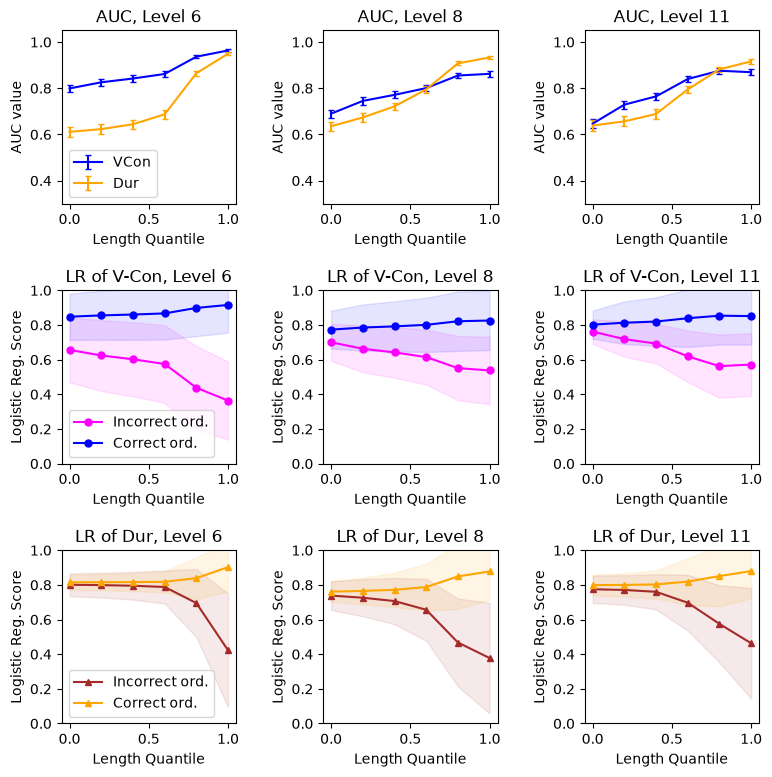

In [9]:
fig, ax = plt.subplots(ncols=3, nrows=3)
plt.subplots_adjust(wspace=0.5, hspace=0.5)
fig.set_size_inches(9, 9)

for i, lvl in enumerate(levels_use):

    ax[0, i].set_ylim([0.3, 1.05])
    ax[0, i].set_ylabel(f'AUC value')
    ax[0, i].set_xlabel(f'Length Quantile')
    ax[0, i].set_title(f'AUC, Level {lvl}')

    if plot_delong:
        mask = delong_df['level'] == lvl
        ax[0, i].errorbar(prop_quantiles, delong_df[mask]['auc2'],
                        yerr=5*delong_df[mask]['auc2_se'],
                        label='VCon', c='blue', capsize=2)
        ax[0, i].errorbar(prop_quantiles, delong_df[mask]['auc1'],
                        yerr=5*delong_df[mask]['auc1_se'],
                        label='Dur', c='orange', capsize=2)
    else:
        ax[0, i].plot(prop_quantiles, np.array(auc_all[lvl]['vector_conformity']), marker='o', label='VCon', c='blue')
        ax[0, i].plot(prop_quantiles, np.array(auc_all[lvl]['duration']), marker='^', label='Dur', c='orange')
    if i == 0:
        ax[0, i].legend()

    for j, metric_name in enumerate(['vector_conformity', 'duration']):
        ax_now = ax[j+1, i]

        # Visiting-order labels and LR scores, as exported by 8_partial_paths
        vocs = vocs_all[lvl]
        logsco_now = np.array(logsco_all[lvl][metric_name]).T

        logsco_now_voc0 = logsco_now[vocs == 0]
        logsco_now_voc1 = logsco_now[vocs == 1]
        logsco_now_voc0_mean = np.mean(logsco_now_voc0, axis=0)
        logsco_now_voc0_std = np.std(logsco_now_voc0, axis=0)
        logsco_now_voc1_mean = np.mean(logsco_now_voc1, axis=0)
        logsco_now_voc1_std = np.std(logsco_now_voc1, axis=0)

        ax_now.set_ylim([0, 1])
        ax_now.set_xlabel(f'Length Quantile')
        ax_now.set_ylabel(f'Logistic Reg. Score')
        if metric_name == 'vector_conformity':
            metric_name2 = 'V-Conformity'
            metric_name2_short = 'V-Con'
            plot_color1 = 'blue'
            plot_color2 = 'magenta'
            marker = 'o'
        elif metric_name == 'duration':
            metric_name2 = 'Duration'
            metric_name2_short = 'Dur'
            plot_color1 = 'orange'
            plot_color2 = 'brown'
            marker = '^'
        ax_now.set_title(f'LR of {metric_name2_short}, Level {lvl}')


        if i == 0:
            label1 = 'Incorrect ord.'
            label2 = 'Correct ord.'
        else:
            label1 = None
            label2 = None

        ax_now.plot(prop_quantiles, logsco_now_voc0_mean, marker=marker, label=label1, c=plot_color2, markersize=5)
        # ax_now.errorbar(prop_quantiles, 
        #                 logsco_now_voc0_mean,
        #                 yerr=logsco_now_voc0_std, 
        #                 color=plot_color2, alpha=0.5, capsize=2)
        ax_now.fill_between(prop_quantiles, 
                        logsco_now_voc0_mean - logsco_now_voc0_std,
                        logsco_now_voc0_mean + logsco_now_voc0_std, 
                        alpha=0.1, color=plot_color2)
        
        ax_now.plot(prop_quantiles, logsco_now_voc1_mean, marker=marker, label=label2, c=plot_color1, markersize=5)
        # ax_now.errorbar(prop_quantiles, 
        #                 logsco_now_voc1_mean,
        #                 yerr=logsco_now_voc1_std, 
        #                 color=plot_color1, alpha=0.5, capsize=2)
        ax_now.fill_between(prop_quantiles,
                        logsco_now_voc1_mean - logsco_now_voc1_std,
                        logsco_now_voc1_mean + logsco_now_voc1_std, 
                        alpha=0.1, color=plot_color1)

        if i == 0:
            ax_now.legend()

# Source data: the DeLong results (from 9_delong_tests.r) behind the AUC panels
save_figure(fig, "partial_path_delong", data={"delong_results": delong_df} if plot_delong else None)